# An Intro to Data Visualization with Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("datasets/diamonds.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
print("This diamonds dataset consists of:")
print("Number of rows", df.shape[0])
print("Number of columns", df.shape[1])

This diamonds dataset consists of:
Number of rows 53940
Number of columns 11


In [5]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [7]:
df_cols = df.columns.to_list()

for i, col in enumerate(df_cols):
    print(f"{i+1}th column: {col}")

1th column: Unnamed: 0
2th column: carat
3th column: cut
4th column: color
5th column: clarity
6th column: depth
7th column: table
8th column: price
9th column: x
10th column: y
11th column: z


## *Basic Plots using Matplotlib*

#### *`Line Plot`*

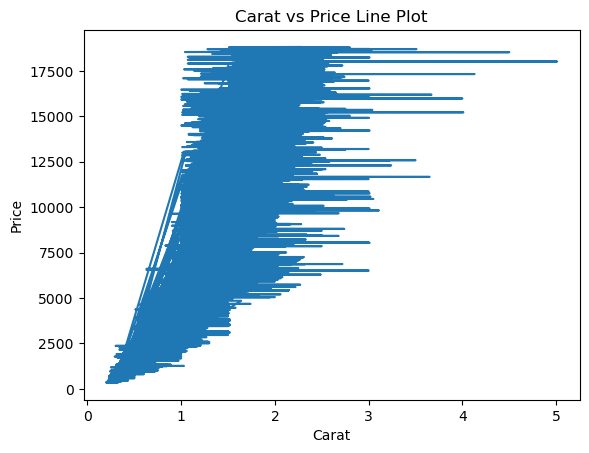

In [8]:
# Line Plot
plt.plot(df["carat"], df["price"])
plt.title("Carat vs Price Line Plot")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

## *`Scatter Plot`*

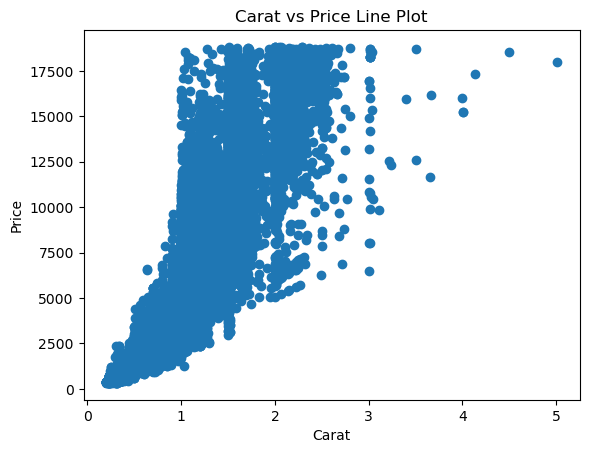

In [9]:
# Line Plot
plt.scatter(df["carat"], df["price"])
plt.title("Carat vs Price Line Plot")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

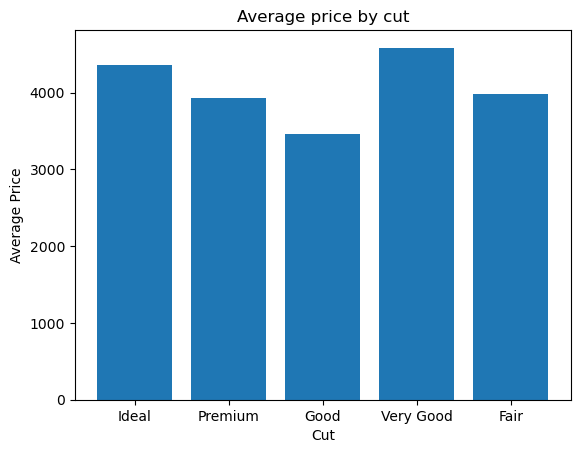

In [10]:
plt.bar(df["cut"].unique(), df.groupby("cut")["price"].mean())
plt.title("Average price by cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.show()

## *`Intermediate Plots in Matplotlib`*

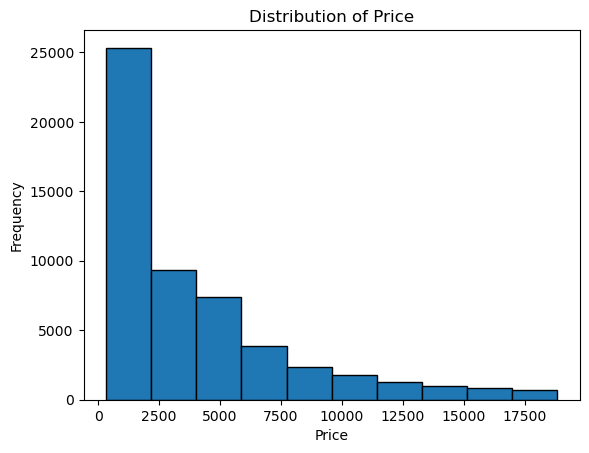

In [11]:
plt.hist(df["price"], bins=10, edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

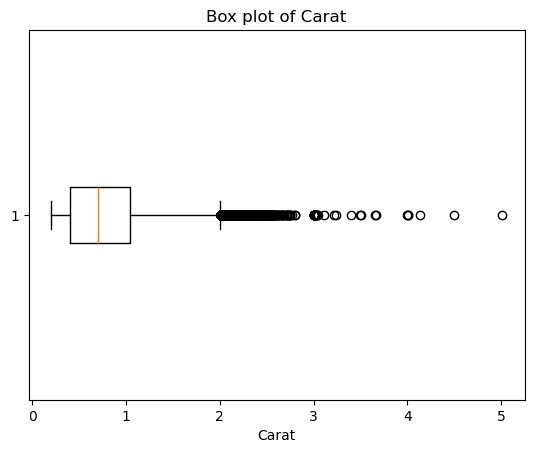

In [12]:
plt.boxplot(df["carat"], vert=False)
plt.title("Box plot of Carat")
plt.xlabel("Carat")
plt.show()

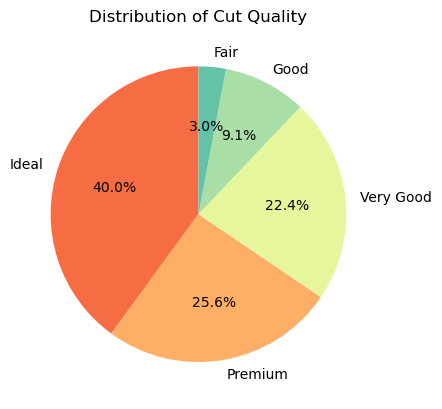

In [13]:
cut_counts = df["cut"].value_counts()
plt.pie(
    cut_counts,
    labels=cut_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#F66D44", "#FEAE65", "#E6F69D", "#AADEA7", "#64C2A6"]
)
plt.title("Distribution of Cut Quality")
plt.show()

In [14]:
df[["carat", "depth", "table", "price", "x", "y", "z"]].corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


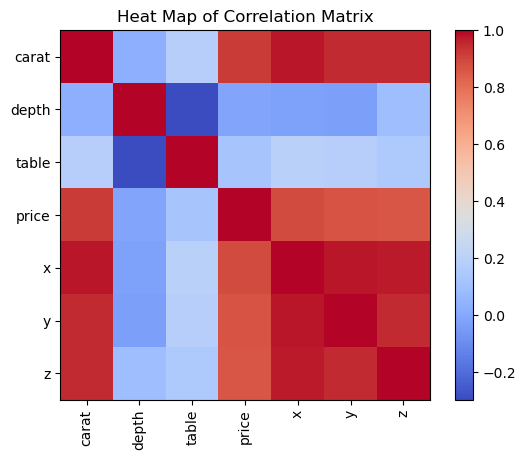

In [15]:
correlation = df[["carat", "depth", "table", "price", "x", "y", "z"]].corr()
plt.imshow(correlation, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(correlation)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation)), correlation.columns)
plt.title("Heat Map of Correlation Matrix")
plt.show()

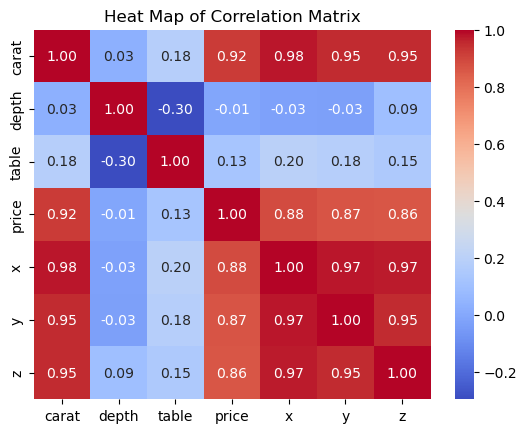

In [16]:
correlation = df[["carat", "depth", "table", "price", "x", "y", "z"]].corr()

sns.heatmap(correlation, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Heat Map of Correlation Matrix")
plt.show()

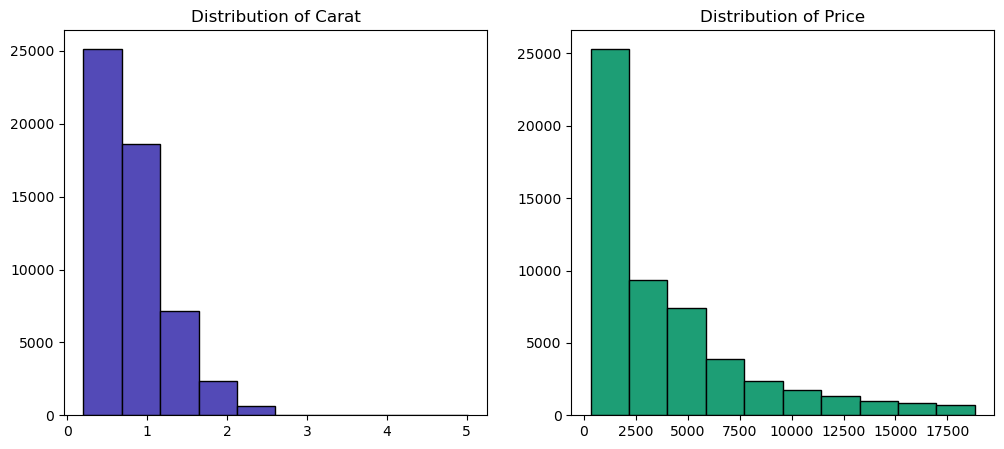

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["carat"], bins=10, edgecolor="black", color="#534AB7")
axes[0].set_title("Distribution of Carat")

axes[1].hist(df["price"], bins=10, edgecolor="black", color="#1D9E75")
axes[1].set_title("Distribution of Price")

plt.show()

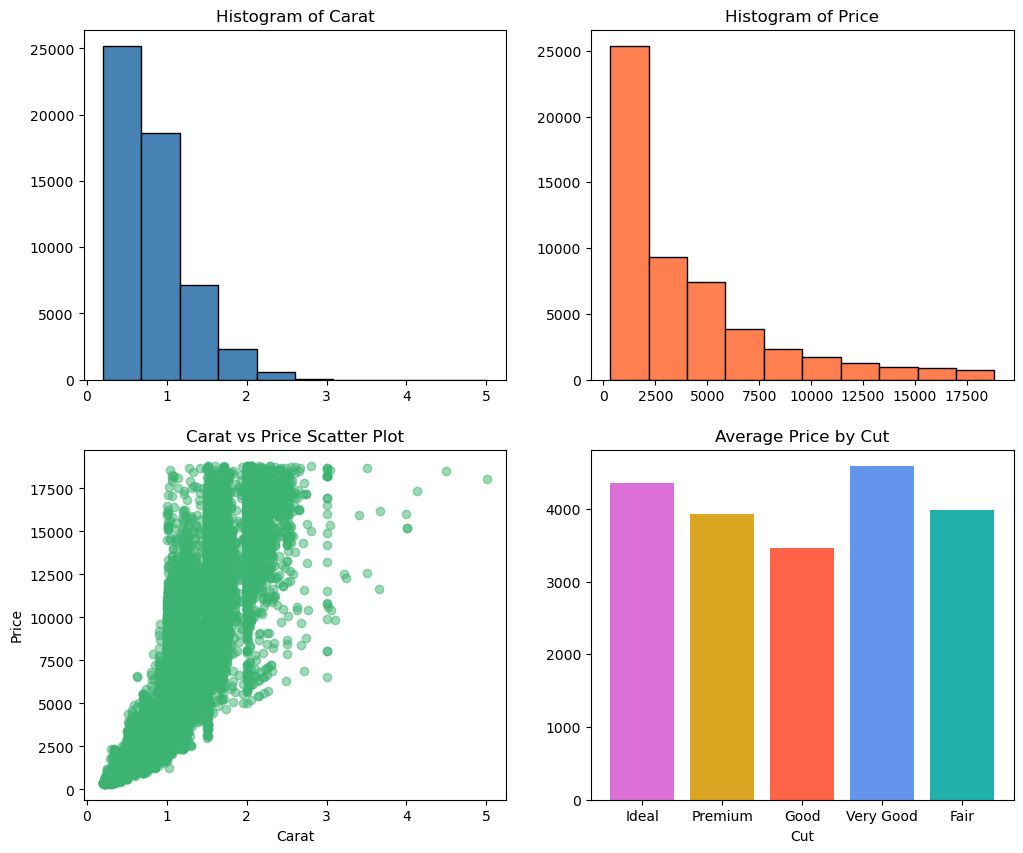

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].hist(df['carat'], bins=10, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Histogram of Carat')
axes[0, 1].hist(df['price'], bins=10, edgecolor='black', color='coral')
axes[0, 1].set_title('Histogram of Price')
axes[1, 0].scatter(df['carat'], df['price'], color='mediumseagreen', alpha=0.5)
axes[1, 0].set_title('Carat vs Price Scatter Plot')
axes[1, 0].set_xlabel('Carat')
axes[1, 0].set_ylabel('Price')
axes[1, 1].bar(df['cut'].unique(), df.groupby('cut')['price'].mean(), color=['orchid', 'goldenrod', 'tomato', 'cornflowerblue', 'lightseagreen'])
axes[1, 1].set_title('Average Price by Cut')
axes[1, 1].set_xlabel('Cut')
plt.show()

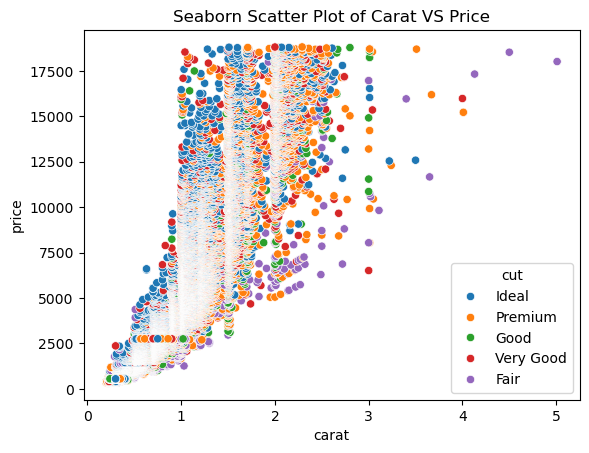

In [21]:
sns.scatterplot(x="carat", y="price", data=df, hue="cut")
plt.title("Seaborn Scatter Plot of Carat VS Price")
plt.show()

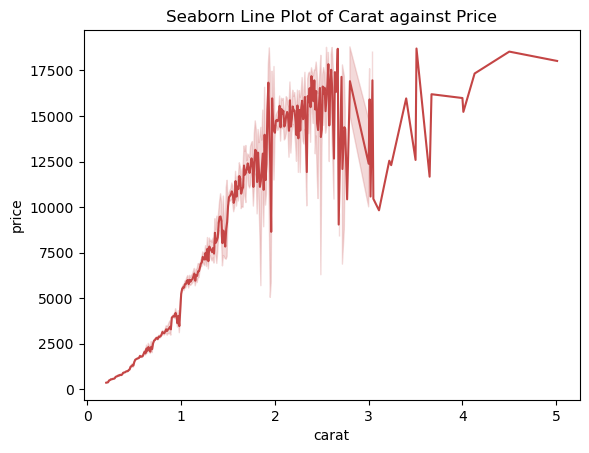

In [29]:
sns.lineplot(x="carat", y="price", data=df, color="#C44545")
plt.title("Seaborn Line Plot of Carat against Price")
plt.show()